### Task 7 - Missing Values and Fare Outliers

1. Missing values:
             Missing Count  Missing Percentage
PassengerId              0            0.000000
Survived                 0            0.000000
Pclass                   0            0.000000
Name                     0            0.000000
Sex                      0            0.000000
Age                    177           19.865320
SibSp                    0            0.000000
Parch                    0            0.000000
Ticket                   0            0.000000
Fare                     0            0.000000
Cabin                  687           77.104377
Embarked                 2            0.224467


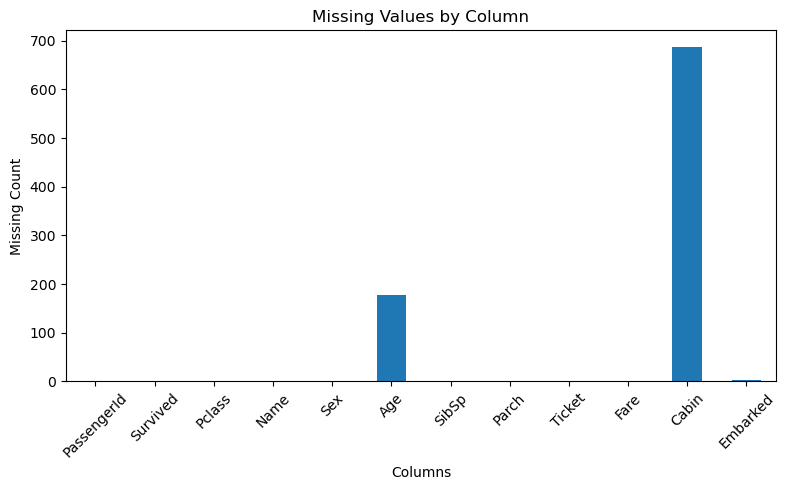

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("train.csv")


missing_count = data.isnull().sum()
missing_percentage = (missing_count / len(data)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print("1. Missing values:")
print(missing_table)


plt.figure(figsize=(8, 5))
missing_count.plot(kind="bar")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.title("Missing Values by Column")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("\n2. Missing Age values before filling:")
print(data["Age"].isnull().sum())


mean_age = data["Age"].mean()
data["Age"] = data["Age"].fillna(mean_age)

print("Missing Age values after filling:")
print(data["Age"].isnull().sum())





2. Missing Age values before filling:
177
Missing Age values after filling:
0


In [ ]:
mean_data = pd.read_csv("train.csv")
median_data = pd.read_csv("train.csv")
mode_data = pd.read_csv("train.csv")
random_data = pd.read_csv("train.csv")


mean_data["Age"] = mean_data["Age"].fillna(mean_data["Age"].mean())

median_data["Age"] = median_data["Age"].fillna(median_data["Age"].median())

mode_value = mode_data["Age"].mode()[0]
mode_data["Age"] = mode_data["Age"].fillna(mode_value)


np.random.seed(42)

missing = random_data["Age"].isnull()
random_values = np.random.choice(
    random_data["Age"].dropna(),
    size=missing.sum()
)

random_data.loc[missing, "Age"] = random_values


print("\n3. Missing Age values after imputation:")
print("Mean   :", mean_data["Age"].isnull().sum())
print("Median :", median_data["Age"].isnull().sum())
print("Mode   :", mode_data["Age"].isnull().sum())
print("Random :", random_data["Age"].isnull().sum())




3. Missing Age values after imputation:
Mean   : 0
Median : 0
Mode   : 0
Random : 0


In [ ]:
Q1 = data["Fare"].quantile(0.25)
Q3 = data["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data["Fare"] < lower_bound) |
    (data["Fare"] > upper_bound)
]

print("\n4. Fare Outlier Analysis:")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))


4. Fare Outlier Analysis:
Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344
Number of Outliers: 116
